<a href="https://colab.research.google.com/github/epashkeeva-ui/project_p/blob/%D0%9A%D1%83%D0%BF%D1%87%D0%B0-%D0%A1%D0%BE%D1%84%D1%8C%D1%8F/poisk_voditelya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
import time
import re
import pandas as pd
from bs4 import BeautifulSoup

In [7]:
class HHParser:
    #Парсит вакансии с hh.ru и считает статистику по зарплатам

    HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

    def __init__(self, query, area=1):
        self.query = query
        self.area = area        # регион (1 = Москва)
        self.df = None

    def get_links(self):
        #Собирает ссылки на карточки вакансий со страницы поиска
        response = requests.get("https://hh.ru/search/vacancy", params={"text": self.query, "area": self.area}, headers=self.HEADERS,)
        soup = BeautifulSoup(response.text, "html.parser")

        links = []
        for a in soup.find_all("a", {"data-qa": "serp-item__title"}):
            clean_url = a.get("href", "").split("?")[0]
            if "/vacancy/" in clean_url:
                links.append(clean_url)

        return list(set(links))

    def parse_card(self, url):
        response = requests.get(url, headers=self.HEADERS)
        soup = BeautifulSoup(response.text, "html.parser")

        title_el = soup.find(attrs={"data-qa": "vacancy-title"})
        name = title_el.get_text(strip=True) if title_el else ""

        salary_el = soup.find(attrs={"data-qa": "vacancy-salary-compensation-type-net"})
        if not salary_el:
            salary_el = soup.find(attrs={"data-qa": "vacancy-salary-compensation-type-gross"})
        salary_text = salary_el.get_text(" ", strip=True) if salary_el else ""

        numbers = re.findall(r"\d[\d\s]*\d", salary_text.replace("\xa0", " "))
        numbers = [int(n.replace(" ", "")) for n in numbers]
        salary_from = numbers[0] if len(numbers) >= 1 else None
        salary_to = numbers[1] if len(numbers) >= 2 else None

        company_el = soup.find(attrs={"data-qa": "vacancy-company-name"})
        company = company_el.get_text(strip=True) if company_el else ""

        return {
            "name": name,
            "salary_from": salary_from,
            "salary_to": salary_to,
            "salary_text": salary_text,
            "company": company,
            "url": url,
        }

    @staticmethod
    def avg_salary(row):
        f, t = row["salary_from"], row["salary_to"]
        if f is not None and t is not None:
            return (f + t) / 2
        if f is not None:
            return f
        if t is not None:
            return t
        return None

    def parse_all(self):
        #Парсит все вакансии и сохраняет в датафрейм
        links = self.get_links()
        print(f"Найдено ссылок на вакансии: {len(links)}")

        vacancies = []
        for i, url in enumerate(links, 1):
            vac = self.parse_card(url)
            vacancies.append(vac)
            time.sleep(0.5)

        df = pd.DataFrame(vacancies)
        df["salary_avg"] = df.apply(self.avg_salary, axis=1)
        self.df = df
        return df

    def stats(self):
        #Считает статистику по зарплатам
        # Убираем вакансии без зарплаты и аномалии
        clean = self.df.dropna(subset=["salary_avg"])
        clean = clean[clean["salary_avg"] >= 50000]

        print(f"\nСтатистика: '{self.query}'")
        print(f"Вакансий всего:         {len(self.df)}")
        print(f"С адекватной зарплатой: {len(clean)}")
        print()
        print(f"Средняя зарплата:  {clean['salary_avg'].mean():,.0f} ₽")
        print(f"Медиана:           {clean['salary_avg'].median():,.0f} ₽")
        print(f"Минимум:           {clean['salary_avg'].min():,.0f} ₽")

        min_row = clean.loc[clean["salary_avg"].idxmin()]
        print()
        print(f"Минимальная зарплата:  {min_row['salary_avg']:,.0f} ₽")
        print(f"  Вакансия:  {min_row['name']}")
        print(f"  Компания:  {min_row['company']}")
        print(f"  Ссылка:    {min_row['url']}")

        return clean

In [8]:
refrigerator = HHParser(query="водитель рефрижератора")
df_refrigerator = refrigerator.parse_all()
refrigerator.stats()

Найдено ссылок на вакансии: 17

Статистика: 'водитель рефрижератора'
Вакансий всего:         17
С адекватной зарплатой: 9

Средняя зарплата:  209,556 ₽
Медиана:           225,000 ₽
Минимум:           130,000 ₽

Минимальная зарплата:  130,000 ₽
  Вакансия:  Водитель-экспедитор (Категории В)
  Компания:  Мясницкий ряд
  Ссылка:    https://hh.ru/vacancy/133286608


,name,salary_from,salary_to,salary_text,company,url,salary_avg
0,Водитель-экспедитор (Категории В),120000.0,140000.0,от 120 000 до 140 000 ₽ за месяц на руки,Мясницкий ряд,https://hh.ru/vacancy/133286608,130000.0
2,Водитель категории С,147000.0,175000.0,от 147 000 до 175 000 ₽ за месяц на руки,ОООФреш Мил,https://hh.ru/vacancy/132855217,161000.0
4,Водитель с личным рефрижератором,220000.0,300000.0,от 220 000 до 300 000 ₽ за месяц на руки,"Протек, Центр Внедрения",https://hh.ru/vacancy/127784664,260000.0
6,Водитель-экспедитор категории Е (дальнобойщик),220000.0,230000.0,от 220 000 до 230 000 ₽ за месяц на руки,ОООТГЛ-Транс,https://hh.ru/vacancy/133011117,225000.0
7,Водитель-экспедитор на своем рефрижераторе,220000.0,330000.0,от 220 000 до 330 000 ₽ за месяц на руки,"Протек, Центр Внедрения",https://hh.ru/vacancy/125262668,275000.0
8,Водитель категории Е (МиМО и ЦФО),220000.0,260000.0,от 220 000 до 260 000 ₽ за месяц на руки,ПродТранс,https://hh.ru/vacancy/133216444,240000.0
9,Водитель-экспедитор категории СЕ на рефрижератор,220000.0,300000.0,от 220 000 до 300 000 ₽ за месяц на руки,ОООРТЭ,https://hh.ru/vacancy/132563803,260000.0
12,Водитель-экспедитор (Категории В),120000.0,140000.0,от 120 000 до 140 000 ₽ за месяц на руки,Мясницкий ряд,https://hh.ru/vacancy/132849568,130000.0
15,"Водитель категории ""Е"" на рефрижератор",190000.0,220000.0,от 190 000 до 220 000 ₽ за месяц на руки,ОООСИЯНИЕ ТК,https://hh.ru/vacancy/133034429,205000.0


In [9]:
gazel = HHParser(query="водитель газель")
df_gazel = gazel.parse_all()
gazel.stats()

Найдено ссылок на вакансии: 19

Статистика: 'водитель газель'
Вакансий всего:         19
С адекватной зарплатой: 10

Средняя зарплата:  132,050 ₽
Медиана:           130,000 ₽
Минимум:           97,500 ₽

Минимальная зарплата:  97,500 ₽
  Вакансия:  Водитель-экспедитор на Газель Next
  Компания:  ДЖЕЙКЕТ РАБОТА
  Ссылка:    https://hh.ru/vacancy/133128386


,name,salary_from,salary_to,salary_text,company,url,salary_avg
0,Водитель-экспедитор (Категории В),120000,140000.0,от 120 000 до 140 000 ₽ за месяц на руки,Мясницкий ряд,https://hh.ru/vacancy/133286608,130000.0
1,Водитель-экспедитор на Газель Next,85000,110000.0,от 85 000 до 110 000 ₽ за месяц до вычета налогов,ДЖЕЙКЕТ РАБОТА,https://hh.ru/vacancy/133128386,97500.0
5,Водитель служебного автомобиля Газель,90000,120000.0,от 90 000 до 120 000 ₽ за месяц на руки,ОООПФ Трио-сервис,https://hh.ru/vacancy/132828534,105000.0
6,Водитель на автомобиле компании Газель Next,125000,135000.0,от 125 000 до 135 000 ₽ за месяц до вычета нал...,ОООВаковия,https://hh.ru/vacancy/133357365,130000.0
8,Водитель-экспедитор,110000,115000.0,от 110 000 до 115 000 ₽ за месяц на руки,ОООТорговая группа Глобал-Вет,https://hh.ru/vacancy/133213891,112500.0
10,Водитель-экспедитор,115000,196000.0,от 115 000 до 196 000 ₽ за месяц до вычета нал...,АОХлебозавод №28,https://hh.ru/vacancy/127653330,155500.0
11,Водитель Газели с категорией BE (CE / DE),130000,210000.0,от 130 000 до 210 000 ₽ за месяц на руки,ОООСтрой-Про,https://hh.ru/vacancy/132665752,170000.0
12,Водитель-экспедитор,120000,140000.0,от 120 000 до 140 000 ₽ за месяц до вычета нал...,Sunny Fitness,https://hh.ru/vacancy/132311900,130000.0
13,Водитель на собственной машине (микроавтобус/ ...,150000,180000.0,от 150 000 до 180 000 ₽ за месяц на руки,ОООПортобелло Продактс,https://hh.ru/vacancy/132525157,165000.0
17,Водитель,100000,150000.0,от 100 000 до 150 000 ₽ за месяц на руки,ОООСмоленск-МБИ,https://hh.ru/vacancy/133337793,125000.0


In [18]:
ref_min = refrigerator.df.query("salary_avg >= 50000")["salary_avg"].min()
gaz_min = gazel.df.query("salary_avg >= 50000")["salary_avg"].min()

print("СРАВНЕНИЕ ЗАТРАТ НА ВОДИТЕЛЕЙ\n")
print(f"Водитель рефрижератора:  {ref_min:,.0f} p")
print(f"Водитель Газели:         {gaz_min:,.0f} p")
print(f"\nРазница: {ref_min - gaz_min:,.0f} p")

СРАВНЕНИЕ ЗАТРАТ НА ВОДИТЕЛЕЙ

Водитель рефрижератора:  130,000 p
Водитель Газели:         97,500 p

Разница: 32,500 p


/tmp/ipykernel_7054/2549510716.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


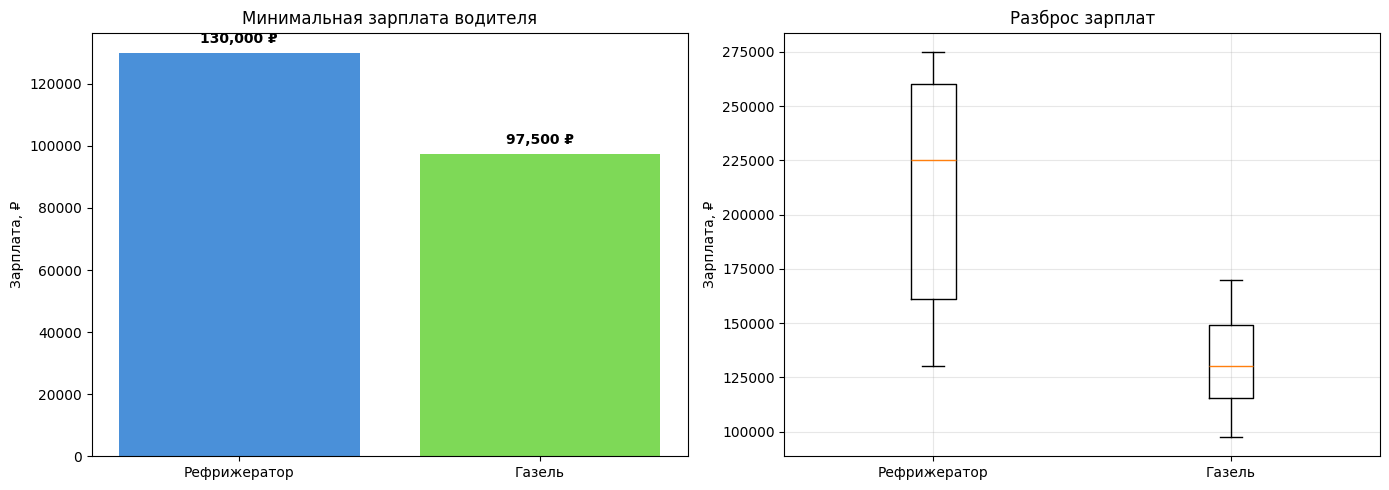

In [19]:
import matplotlib.pyplot as plt

ref_clean = refrigerator.df.dropna(subset=["salary_avg"])
ref_clean = ref_clean[ref_clean["salary_avg"] >= 50000]

gaz_clean = gazel.df.dropna(subset=["salary_avg"])
gaz_clean = gaz_clean[gaz_clean["salary_avg"] >= 50000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

professions = ["Рефрижератор", "Газель"]
min_salaries = [ref_clean["salary_avg"].min(), gaz_clean["salary_avg"].min()]

bars = axes[0].bar(professions, min_salaries, color=["#4A90D9", "#7ED957"])
axes[0].set_title("Минимальная зарплата водителя")
axes[0].set_ylabel("Зарплата, ₽")

for bar, value in zip(bars, min_salaries):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f"{value:,.0f} ₽",
        ha="center",
        fontweight="bold",
    )

axes[1].boxplot(
    [ref_clean["salary_avg"], gaz_clean["salary_avg"]],
    labels=professions,
)
axes[1].set_title("Разброс зарплат")
axes[1].set_ylabel("Зарплата, ₽")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

В любом случае слишком дорого, не берем водителя.